# 06. SMOTE

Weighted loss and focal loss leave the training distribution untouched — they compensate for imbalance by changing how the loss is computed, not what data the model sees. SMOTE takes a different approach: it rebalances the training set directly by generating synthetic minority-class samples.

For each minority-class sample, SMOTE picks k nearest neighbors in the same class, then interpolates a new point along the line between the original and a randomly chosen neighbor:

```
synthetic = x_i + lambda * (x_neighbor - x_i)   where lambda ~ Uniform(0, 1)
```

Unlike random oversampling (which duplicates existing samples), SMOTE generates novel points that lie between real examples in feature space.

**Why training data only**: SMOTE must never touch the test set. Applying it before the split would leak test-set geometry into training. Here we load the pre-split `beats_split.npz` and apply SMOTE only to `X_train`.

**Baseline to beat**: Weighted CE — macro F1 0.30, V F1 0.59.

## Load Data

In [1]:
import numpy as np

npz = np.load('../data/processed/beats_split.npz')
X_train = npz['X_train']  # (N, 360) float32
y_train = npz['y_train']  # (N,)     int64
X_test  = npz['X_test']
y_test  = npz['y_test']

print('Before SMOTE:')
print(f'  X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'  X_test:  {X_test.shape},  y_test:  {y_test.shape}')

unique, counts = np.unique(y_train, return_counts=True)
print('\nClass distribution (train):')
for cls, cnt in zip(unique, counts):
    print(f'  class {cls}: {cnt}')

Before SMOTE:
  X_train: (50995, 360), y_train: (50995,)
  X_test:  (49687, 360),  y_test:  (49687,)

Class distribution (train):
  class 0: 45841
  class 1: 944
  class 2: 3788
  class 3: 414
  class 4: 8


## Apply SMOTE

In [4]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After SMOTE:')
print(Counter(y_train_sm.tolist()))
print(f'X_train_sm shape: {X_train_sm.shape}')

After SMOTE:
Counter({0: 45841, 4: 45841, 1: 45841, 2: 45841, 3: 45841})
X_train_sm shape: (229205, 360)


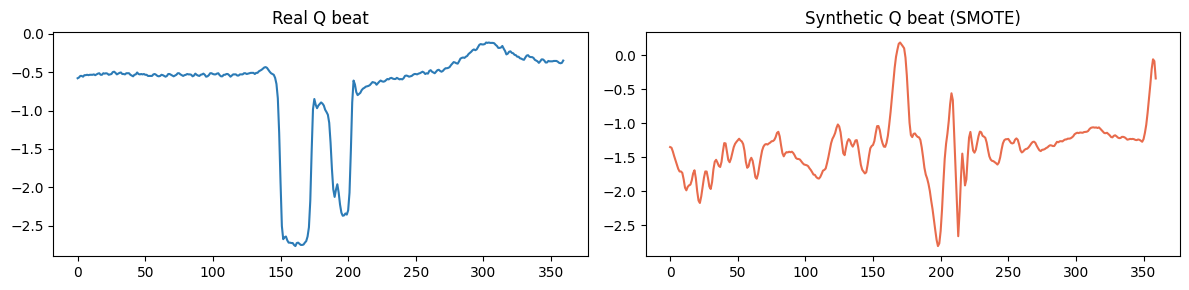

In [5]:
import matplotlib.pyplot as plt

# original Q beats
real_q = X_train[y_train == 4]

# synthetic Q beats (everything after the original 8)
all_q = X_train_sm[y_train_sm == 4]
synthetic_q = all_q[8:]  # first 8 are originals

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(real_q[0], color='#2C7BB6')
axes[0].set_title('Real Q beat')
axes[1].plot(synthetic_q[0], color='#E86B4C')
axes[1].set_title('Synthetic Q beat (SMOTE)')

plt.tight_layout()
plt.show()

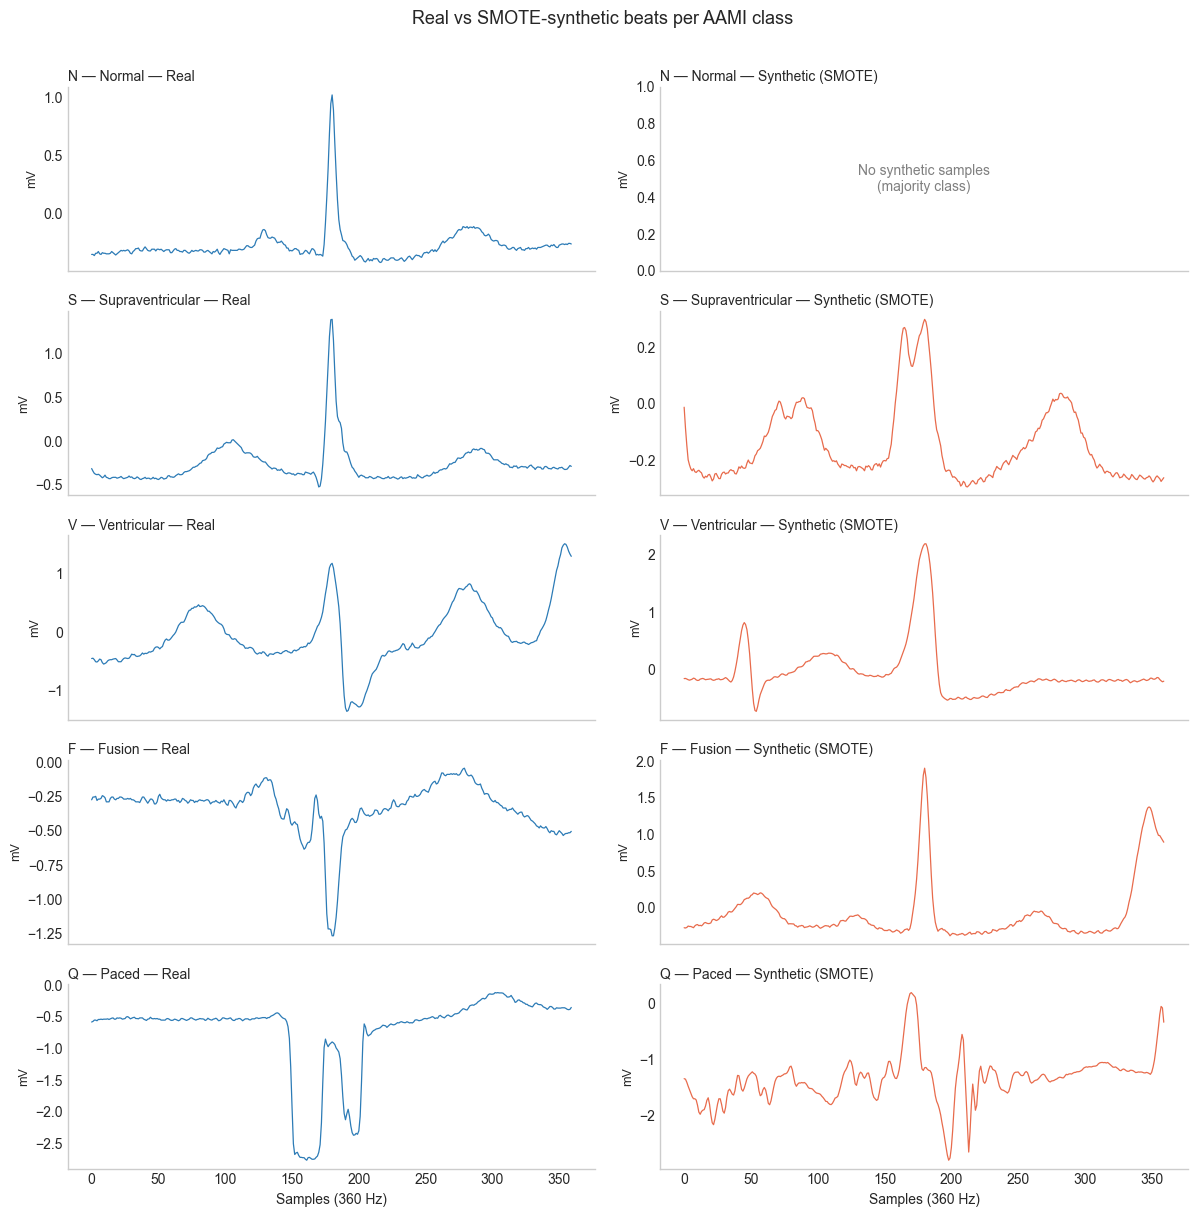

In [10]:
from src.data_loader import CLASS_NAMES

CLASS_LABELS = {
    'N': 'N — Normal',
    'S': 'S — Supraventricular',
    'V': 'V — Ventricular',
    'F': 'F — Fusion',
    'Q': 'Q — Paced',
}

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(5, 2, figsize=(12, 12), sharex=True)

for i, label in enumerate(CLASS_NAMES):
    real      = X_train[y_train == i]
    all_class = X_train_sm[y_train_sm == i]
    synthetic = all_class[len(real):]

    # left panel — real
    axes[i, 0].plot(real[0], color='#2C7BB6', linewidth=0.9)
    axes[i, 0].set_title(f'{CLASS_LABELS[label]} — Real', fontsize=10, loc='left', pad=4)
    axes[i, 0].set_ylabel('mV', fontsize=9)
    axes[i, 0].grid(False)
    axes[i, 0].spines[['top', 'right']].set_visible(False)

    # right panel — synthetic
    if len(synthetic) == 0:
        axes[i, 1].text(0.5, 0.5, 'No synthetic samples\n(majority class)',
                        ha='center', va='center', transform=axes[i, 1].transAxes,
                        fontsize=10, color='gray')
        axes[i, 1].set_title(f'{CLASS_LABELS[label]} — Synthetic (SMOTE)', fontsize=10, loc='left', pad=4)
    else:
        axes[i, 1].plot(synthetic[0], color='#E86B4C', linewidth=0.9)
        axes[i, 1].set_title(f'{CLASS_LABELS[label]} — Synthetic (SMOTE)', fontsize=10, loc='left', pad=4)

    axes[i, 1].set_ylabel('mV', fontsize=9)
    axes[i, 1].grid(False)
    axes[i, 1].spines[['top', 'right']].set_visible(False)

axes[-1, 0].set_xlabel('Samples (360 Hz)', fontsize=10)
axes[-1, 1].set_xlabel('Samples (360 Hz)', fontsize=10)
fig.suptitle('Real vs SMOTE-synthetic beats per AAMI class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Training

In [14]:
from torch.utils.data import TensorDataset, DataLoader
import torch


X_train_sm_t = torch.tensor(X_train_sm, dtype=torch.float32).unsqueeze(1)  # (N, 1, 360)
y_train_sm_t = torch.tensor(y_train_sm, dtype=torch.long)
X_test_t     = torch.tensor(X_test,     dtype=torch.float32).unsqueeze(1)
y_test_t     = torch.tensor(y_test,     dtype=torch.long)

train_ds = TensorDataset(X_train_sm_t, y_train_sm_t)
test_ds  = TensorDataset(X_test_t,     y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 3582
Test batches:  777


In [16]:
from src.model import ECGNet
from torch import nn

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

model     = ECGNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f'Device: {device}')

Device: mps


In [17]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        # 1. move to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        # 2. zero gradients
        optimizer.zero_grad()
        # 3. forward pass
        y_pred = model(X_batch)
        # 4. compute loss
        loss = criterion(y_pred, y_batch)
        # 5. backward pass
        loss.backward()
        # 6. optimizer step
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
    
    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    

Epoch [1/10], Loss: 0.9596
Epoch [2/10], Loss: 0.6820
Epoch [3/10], Loss: 0.5715
Epoch [4/10], Loss: 0.5216
Epoch [5/10], Loss: 0.4852
Epoch [6/10], Loss: 0.4560
Epoch [7/10], Loss: 0.4341
Epoch [8/10], Loss: 0.4134
Epoch [9/10], Loss: 0.3951
Epoch [10/10], Loss: 0.3784


## Evaluation

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
from src.data_loader import CLASS_NAMES

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

              precision    recall  f1-score   support

           N       0.96      0.66      0.78     44235
           S       0.11      0.26      0.15      1837
           V       0.38      0.83      0.52      3220
           F       0.01      0.09      0.01       388
           Q       0.00      0.14      0.00         7

    accuracy                           0.65     49687
   macro avg       0.29      0.40      0.29     49687
weighted avg       0.88      0.65      0.73     49687

